# Vietnamese Text Preprocessing Pipeline for Emotion Classification

This notebook performs end-to-end data preprocessing:

1. **Load & Inspect** – Load raw data, display schema, check for missing values.
2. **Text Cleaning** – Replace emojis, text emoticons, abbreviations; strip URLs, HTML, special chars.
3. **Deduplication** – Drop duplicate sentences.
4. **Validation & Visualisation** – Emotion distribution, text-length statistics.
5. **Export** – Save the cleaned dataset.

> **Note:** Stopwords are intentionally *not* removed because BERT-based models (e.g. CafeBERT) rely on self-attention over **all** tokens, including words like *không* (negation) and *rất* (very).

## 0. Configuration & Imports

In [165]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [166]:
import os
import re
from pathlib import Path
from collections import Counter
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# --- Robust PROJECT_ROOT detection (works in Jupyter/IPython or .py) ---
def get_project_root():
    try:
        # If in a script context
        root = Path(__file__).resolve().parent.parent
    except NameError:
        # If in Jupyter or __file__ not defined, use notebook location or cwd
        root = Path(os.getcwd())
        # Heuristic: climb up if inside tm_research/ (for direct notebook run)
        if root.name == 'tm_research':
            root = root.parent
        elif (root / 'tm_research').exists():
            root = root / 'tm_research'
    return root

PROJECT_ROOT = get_project_root()
DATA_DIR     = PROJECT_ROOT / 'tm_research' / 'data' / 'processed'

INPUT_FILE   = DATA_DIR / 'train_1500_para_processed.csv'
OUTPUT_FILE  = DATA_DIR / 'train_1500_para_final.csv'

TEXT_COL     = 'Sentence'
LABEL_COL    = 'Emotion'
LABEL_VN_COL = 'emotion_vn'
CLEAN_COL    = 'Sentence_clean'

RANDOM_SEED  = 42

print(f'Input  : {INPUT_FILE}')
print(f'Output : {OUTPUT_FILE}')

Input  : /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1500_para_processed.csv
Output : /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1500_para_final.csv


## 1. Data Loading & Inspection

In [167]:
df = pd.read_csv(INPUT_FILE)

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}\n')
df.info()
df.head()

Shape  : (10558, 3)
Columns: ['Sentence', 'Emotion', 'emotion_vn']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10558 entries, 0 to 10557
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sentence    10558 non-null  object
 1   Emotion     10558 non-null  object
 2   emotion_vn  10558 non-null  object
dtypes: object(3)
memory usage: 247.6+ KB


,Sentence,Emotion,emotion_vn
0,cho mình xin bài nhạc tên là gì với ạ,Other,khác
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust,khó chịu
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust,khó chịu
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment,vui vẻ
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment,vui vẻ


In [168]:
required_cols = [TEXT_COL, LABEL_COL]
for c in required_cols:
    assert c in df.columns, f'Missing required column: {c}'

print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

keep_cols = [c for c in [TEXT_COL, LABEL_COL, LABEL_VN_COL] if c in df.columns]
df = df[keep_cols].copy()
print(f'\nKept columns: {df.columns.tolist()}')
print(f'Shape after column selection: {df.shape}')

Missing values per column:
Sentence      0
Emotion       0
emotion_vn    0
dtype: int64

Total missing: 0

Kept columns: ['Sentence', 'Emotion', 'emotion_vn']
Shape after column selection: (10558, 3)


In [169]:
print('Emotion label distribution (raw):')
print(df[LABEL_COL].value_counts())
print(f'\nUnique labels: {sorted(df[LABEL_COL].unique())}')

Emotion label distribution (raw):
Emotion
Enjoyment    1558
Other        1500
Disgust      1500
Anger        1500
Surprise     1500
Sadness      1500
Fear         1500
Name: count, dtype: int64

Unique labels: ['Anger', 'Disgust', 'Enjoyment', 'Fear', 'Other', 'Sadness', 'Surprise']


## 2. Define Preprocessing Components

In [170]:
from tm_research.text_preprocess import (
    EMOJI_TO_VIETNAMESE, TEXT_EMOTICONS, ABBREVIATIONS,
    preprocess_vietnamese_text,
    replace_emojis, replace_text_emoticons, replace_abbreviations,
    normalize_elongated_characters, remove_numbers, clean_special_characters,
)

print(f'Emoji mappings       : {len(EMOJI_TO_VIETNAMESE)}')
print(f'Text-emoticon mappings: {len(TEXT_EMOTICONS)}')
print(f'Abbreviation mappings : {len(ABBREVIATIONS)}')
    '😅': 'vui vẻ', '🤣': 'cười lớn', '😂': 'cười lớn', '🙂': 'mỉm cười', '🙃': 'mỉm cười',
    '😉': 'nháy mắt', '😊': 'hạnh phúc', '😇': 'thiên thần', '🥰': 'yêu thương',
    '😍': 'yêu thích', '🤩': 'ngưỡng mộ', '😘': 'hôn', '😗': 'hôn', '☺️': 'hạnh phúc',
    '😚': 'hôn', '😙': 'hôn', '🥲': 'vui buồn lẫn lộn',
    '❤️': 'yêu thương', '💕': 'yêu thương', '💗': 'yêu thương', '💖': 'yêu thương',
    '💘': 'yêu thương', '💝': 'yêu thương', '💞': 'yêu thương', '💓': 'yêu thương',
    '💜': 'yêu thương', '💙': 'yêu thương', '💚': 'yêu thương', '🧡': 'yêu thương',
    '🖤': 'yêu thương', '🤍': 'yêu thương', '🤎': 'yêu thương', '💛': 'yêu thương',
    '😢': 'buồn bã', '😭': 'khóc', '😿': 'buồn bã', '😞': 'thất vọng',
    '😔': 'buồn bã', '😟': 'lo lắng', '😕': 'bối rối', '🙁': 'buồn bã',
    '☹️': 'buồn bã', '😣': 'đau khổ', '😖': 'khó chịu', '😫': 'mệt mỏi',
    '😩': 'mệt mỏi', '🥺': 'van xin', '😪': 'buồn ngủ', '😥': 'lo lắng',
    '😠': 'tức giận', '😡': 'tức giận', '🤬': 'tức giận', '😤': 'bực tức',
    '💢': 'tức giận', '👿': 'tức giận', '😈': 'tinh nghịch',
    '😨': 'sợ hãi', '😰': 'lo sợ', '😱': 'kinh hãi', '🥶': 'lạnh',
    '😮': 'ngạc nhiên', '😯': 'ngạc nhiên', '😲': 'sửng sốt', '😳': 'xấu hổ',
    '🤯': 'choáng váng', '😬': 'căng thẳng', '🙀': 'sợ hãi',
    '🤢': 'buồn nôn', '🤮': 'ghê tởm', '😷': 'bệnh', '🤧': 'hắt xì',
    '🤒': 'ốm', '🤕': 'đau', '😵': 'chóng mặt', '🥴': 'say',
    '🤔': 'suy nghĩ', '🤨': 'nghi ngờ', '😐': 'bình thường', '😑': 'bình thường',
    '😶': 'im lặng', '🙄': 'chán', '😏': 'ranh mãnh', '😒': 'không hài lòng',
    '🤗': 'ôm', '🤭': 'che miệng cười', '🤫': 'im lặng', '🤥': 'nói dối',
    '😴': 'ngủ', '💤': 'ngủ', '👍': 'tốt', '👎': 'tệ', '👌': 'được',
    '✌️': 'chiến thắng', '🤞': 'chúc may mắn', '🙏': 'cầu nguyện',
    '💪': 'mạnh mẽ', '🔥': 'nóng bỏng', '✨': 'lấp lánh', '🌟': 'ngôi sao',
    '💯': 'hoàn hảo', '😎': 'ngầu', '🤓': 'thông minh', '🥳': 'ăn mừng',
    '😋': 'ngon', '🤤': 'thèm', '😜': 'tinh nghịch', '😝': 'tinh nghịch',
    '😛': 'lè lưỡi', '🤪': 'điên', '👀': 'nhìn', '👁️': 'nhìn',
}

TEXT_EMOTICONS = {
    ':)': 'vui vẻ', ':-)': 'vui vẻ', '(:': 'vui vẻ',
    ':D': 'cười lớn', ':-D': 'cười lớn',
    ':))': 'cười lớn', ':)))': 'cười lớn', ':))))': 'cười lớn',
    '=))': 'cười lớn', '=)))': 'cười lớn',
    ':3': 'dễ thương',
    ':(': 'buồn bã', ':-(': 'buồn bã', ":'(": 'khóc',
    ':((' : 'buồn bã', ':(((': 'rất buồn',
    ':P': 'tinh nghịch', ':-P': 'tinh nghịch', ':p': 'tinh nghịch',
    ';)': 'nháy mắt', ';-)': 'nháy mắt',
    ':O': 'ngạc nhiên', ':-O': 'ngạc nhiên', ':o': 'ngạc nhiên',
    'o.O': 'ngạc nhiên', 'O.o': 'ngạc nhiên',
    '@@': 'choáng',
    '-_-': 'chán', '-.-': 'chán',
    '>.<': 'khó chịu',
    '^_^': 'vui vẻ', '^.^': 'vui vẻ',
    'T_T': 'khóc', 'T.T': 'khóc',
    '>_<': 'khó chịu',
    '<3': 'yêu thương', '</3': 'tan vỡ',
    ':*': 'hôn', ':-*': 'hôn',
}

ABBREVIATIONS = {
    'ko': 'không', 'k': 'không', 'hok': 'không', 'hem': 'không', 'hông': 'không',
    'dc': 'được', 'đc': 'được', 'đk': 'được', 'dk': 'được', 'đuoc': 'được',
    'vs': 'với', 'voi': 'với', 'v': 'với',
    'mk': 'mình', 'mik': 'mình', 'minh': 'mình',
    'bn': 'bạn', 'pn': 'bạn', 'bạng': 'bạn',
    'cx': 'cũng', 'cg': 'cũng', 'cug': 'cũng',
    'ntn': 'như thế nào', 'sn': 'sao',
    'bh': 'bây giờ', 'bjo': 'bây giờ', 'bjờ': 'bây giờ', 'bgiờ': 'bây giờ',
    'j': 'gì', 'ji': 'gì', 'z': 'vậy', 'zậy': 'vậy', 'r': 'rồi',
    'trc': 'trước', 'trog': 'trong', 'tg': 'thời gian',
    'nt': 'nhắn tin', 'nv': 'nhân vật',
    'ns': 'nói', 'nc': 'nói chuyện', 'nch': 'nói chuyện',
    'bt': 'bình thường', 'bth': 'bình thường', 'binh thuong': 'bình thường',
    'thg': 'thằng', 'thag': 'thằng',
    'ng': 'người', 'ngta': 'người ta', 'nguoi': 'người',
    'ak': 'à', 'ạk': 'ạ', 'nka': 'nhé', 'nhe': 'nhé',
    'gđ': 'gia đình', 'gd': 'gia đình',
    'hj': 'hihi', 'haha': 'haha', 'hihi': 'hihi', 'huhu': 'huhu',
    'kkk': 'haha', 'kk': 'haha', 'wkwk': 'haha',
    'vkl': 'rất', 'vl': 'rất', 'vcl': 'rất',
    'clgt': 'chắc luôn', 'cl': 'chắc luôn',
    'tl': 'trả lời', 'rep': 'trả lời',
    'acc': 'tài khoản', 'fb': 'facebook', 'ib': 'nhắn tin',
    'đt': 'điện thoại', 'dt': 'điện thoại',
    'tv': 'tivi', 'tp': 'thành phố', 'tphcm': 'thành phố hồ chí minh',
    'hn': 'hà nội', 'sg': 'sài gòn',
    'trg': 'trường', 'truong': 'trường',
    'lm': 'làm', 'lam': 'làm',
    'cty': 'công ty', 'cong ty': 'công ty',
    'thang': 'tháng',
    'qtr': 'quan trọng', 'qtrog': 'quan trọng',
    'sp': 'sản phẩm', 'dv': 'dịch vụ',
    'hq': 'hàn quốc', 'tq': 'trung quốc',
    'thik': 'thích', 'tk': 'tài khoản',
    't': 'tao',
}

print(f'Emoji mappings       : {len(EMOJI_TO_VIETNAMESE)}')
print(f'Text-emoticon mappings: {len(TEXT_EMOTICONS)}')
print(f'Abbreviation mappings : {len(ABBREVIATIONS)}')

Emoji mappings       : 116
Text-emoticon mappings: 39
Abbreviation mappings : 95


## 3. Preprocessing Functions

In [171]:
print('Preprocessing functions ready (imported from tm_research.text_preprocess).')
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U00002600-\U000026FF"
    "]+",
    flags=re.UNICODE,
)

_VN_CHARS_RE = re.compile(
    r'[^\w\sàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ.,!?]',
    flags=re.IGNORECASE,
)

_SORTED_EMOTICONS = sorted(TEXT_EMOTICONS.items(), key=lambda x: len(x[0]), reverse=True)

# Reduce elongated alphabetic characters: "soooo" -> "so"
_ELONGATED_CHAR_RE = re.compile(r'([^\W\d_])\1{2,}', flags=re.UNICODE)


def replace_emojis(text: str) -> str:
    for emoji_char, descriptor in EMOJI_TO_VIETNAMESE.items():
        text = text.replace(emoji_char, f' {descriptor} ')
    return _EMOJI_RE.sub(' ', text)


def replace_text_emoticons(text: str) -> str:
    for emoticon, descriptor in _SORTED_EMOTICONS:
        escaped = re.escape(emoticon)
        text = re.sub(escaped, f' {descriptor} ', text)
    return text


def replace_abbreviations(text: str) -> str:
    words = text.split()
    return ' '.join(ABBREVIATIONS.get(w.lower(), w) for w in words)


def normalize_elongated_characters(text: str) -> str:
    return _ELONGATED_CHAR_RE.sub(r'\1', text)


def remove_numbers(text: str) -> str:
    return ' '.join(re.sub(r'\d+', ' ', text).split())


def clean_special_characters(text: str) -> str:
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = _VN_CHARS_RE.sub(' ', text)
    text = re.sub(r'([.,!?])\1+', r'\1', text)
    return re.sub(r'\s+', ' ', text).strip()


def preprocess_vietnamese_text(text: str) -> str:
    if not isinstance(text, str):
        return text
    text = replace_emojis(text)
    text = replace_text_emoticons(text)
    text = replace_abbreviations(text)
    text = normalize_elongated_characters(text)
    text = remove_numbers(text)
    text = clean_special_characters(text)
    return text.lower().strip() if text else text


print('Preprocessing functions ready.')

Preprocessing functions ready.


## 4. Apply Preprocessing

In [172]:
sample_texts = df[TEXT_COL].sample(5, random_state=RANDOM_SEED).tolist()

print('BEFORE preprocessing:')
for i, t in enumerate(sample_texts, 1):
    print(f'  {i}. {t}')

df[CLEAN_COL] = df[TEXT_COL].apply(preprocess_vietnamese_text)

print('\nAFTER preprocessing:')
for i, (orig, clean) in enumerate(
    zip(sample_texts, [preprocess_vietnamese_text(t) for t in sample_texts]), 1
):
    print(f'  {i}. {orig}')
    print(f'     → {clean}\n')

BEFORE preprocessing:
  1. giá mà thằng lái xe ngồi trong xe oto trông xe thì tốt biết mấy !
  2. nó sẽ ra cái ốp , lo gì thiếu đồ chơi
  3. bất ngờ thiệt :))))
  4. Pha này nhìn xịn xò hơn cả bệnh nhân của ông đó nha!
  5. thích bài này lắm lun . thuộc lun

AFTER preprocessing:
  1. giá mà thằng lái xe ngồi trong xe oto trông xe thì tốt biết mấy !
     → giá mà thằng lái xe ngồi trong xe oto trông xe thì tốt biết mấy !

  2. nó sẽ ra cái ốp , lo gì thiếu đồ chơi
     → nó sẽ ra cái ốp , lo gì thiếu đồ chơi

  3. bất ngờ thiệt :))))
     → bất ngờ thiệt cười lớn

  4. Pha này nhìn xịn xò hơn cả bệnh nhân của ông đó nha!
     → pha này nhìn xịn xò hơn cả bệnh nhân của ông đó nha!

  5. thích bài này lắm lun . thuộc lun
     → thích bài này lắm lun . thuộc lun



## 5. Deduplication

In [173]:
before = len(df)
dup_mask = df.duplicated(subset=[CLEAN_COL], keep='first')
n_dups = dup_mask.sum()

print(f'Records before dedup: {before}')
print(f'Duplicates found    : {n_dups}')

if n_dups:
    print('\nExamples of duplicated rows:')
    for idx, row in df[dup_mask].head(3).iterrows():
        print(f'  idx={idx}: {row[CLEAN_COL][:80]}…')

    df = df[~dup_mask].reset_index(drop=True)

print(f'Records after dedup : {len(df)}  (removed {before - len(df)})')

Records before dedup: 10558
Duplicates found    : 17

Examples of duplicated rows:
  idx=1275: per bây giờ thì không nói nhưng mà cảm giác phủ nhận vai trò bà thảo ngày xưa . …
  idx=1411: cưng xỉu ?…
  idx=4386: nguy hiểm lắm…
Records after dedup : 10541  (removed 17)


## 6. Validation & Visualisation

In [174]:
emotion_counts = df[LABEL_COL].value_counts()
total = len(df)

print(f"{'Emotion':<15} {'Count':>8} {'Pct':>8}")
print('-' * 33)
for emotion, count in emotion_counts.items():
    print(f'{emotion:<15} {count:>8} {count/total*100:>7.2f}%')
print('-' * 33)
print(f'{"TOTAL":<15} {total:>8} {"100.00%":>8}')

Emotion            Count      Pct
---------------------------------
Enjoyment           1556   14.76%
Sadness             1500   14.23%
Other               1499   14.22%
Surprise            1499   14.22%
Disgust             1498   14.21%
Anger               1496   14.19%
Fear                1493   14.16%
---------------------------------
TOTAL              10541  100.00%


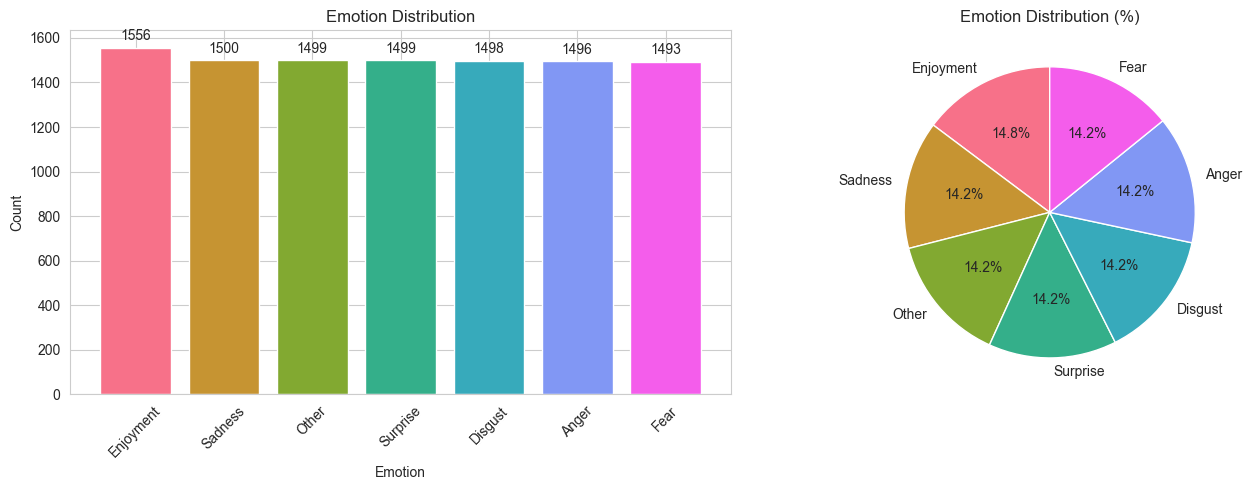

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('husl', len(emotion_counts))

bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].set_title('Emotion Distribution')
axes[0].tick_params(axis='x', rotation=45)
for bar, cnt in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(cnt), ha='center', va='bottom', fontsize=10)

axes[1].pie(emotion_counts.values, labels=emotion_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Emotion Distribution (%)')

plt.tight_layout()
plt.show()

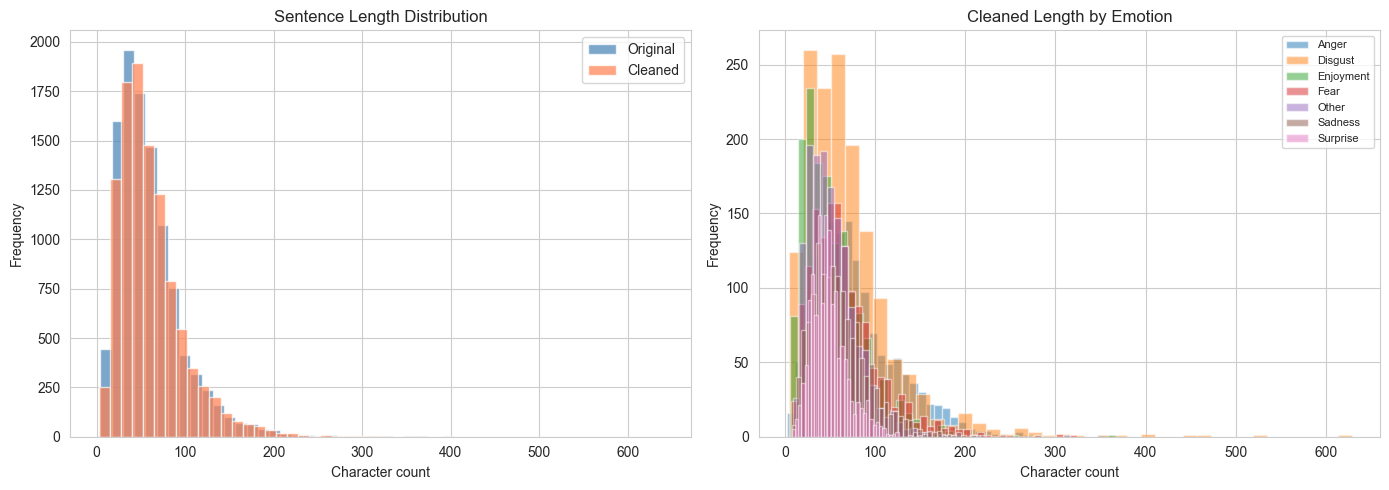

Original  – mean: 59.8, max: 640
Cleaned   – mean: 61.2, max: 629
Avg change: +2.4%


In [176]:
df['_orig_len']  = df[TEXT_COL].str.len()
df['_clean_len'] = df[CLEAN_COL].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['_orig_len'],  bins=50, alpha=0.7, label='Original', color='steelblue')
axes[0].hist(df['_clean_len'], bins=50, alpha=0.7, label='Cleaned',  color='coral')
axes[0].set_title('Sentence Length Distribution')
axes[0].set_xlabel('Character count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

for label in sorted(df[LABEL_COL].unique()):
    subset = df.loc[df[LABEL_COL] == label, '_clean_len']
    axes[1].hist(subset, bins=40, alpha=0.5, label=label)
axes[1].set_title('Cleaned Length by Emotion')
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

mean_orig  = df['_orig_len'].mean()
mean_clean = df['_clean_len'].mean()
pct_change = (mean_clean - mean_orig) / mean_orig * 100

print(f'Original  – mean: {mean_orig:.1f}, max: {df["_orig_len"].max()}')
print(f'Cleaned   – mean: {mean_clean:.1f}, max: {df["_clean_len"].max()}')
print(f'Avg change: {pct_change:+.1f}%')

df.drop(columns=['_orig_len', '_clean_len'], inplace=True)

In [177]:

emotion_map_en2vn = {
    'Anger': 'giận dữ',
    'Fear': 'sợ hãi',
    'Disgust': 'khó chịu',
    'Surprise': 'ngạc nhiên',
    'Sadness': 'buồn',
    'Enjoyment': 'vui vẻ',
    'Other': 'khác'
}
if "emotion_vn" not in df.columns:
    if df[LABEL_COL].isin(emotion_map_en2vn.keys()).all():
        df['emotion_vn'] = df[LABEL_COL].map(emotion_map_en2vn)


## 7. Shuffle & Export

In [178]:
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f'Shuffled. Shape: {df.shape}')
df.head()

Shuffled. Shape: (10541, 4)


,Sentence,Emotion,emotion_vn,Sentence_clean
0,"Quá cẩu thả, vậy mà giam người ta gần 7 năm, g...",Disgust,khó chịu,"quá cẩu thả, vậy mà giam người ta gần năm, giờ..."
1,khi nhỏ còn bị nghiện mùi khói này nữa chớ . 😄,Enjoyment,vui vẻ,khi nhỏ còn bị nghiện mùi khói này nữa chớ . v...
2,Đi ngang qua mấy bận mà lần nào cũng giật bắn ...,Fear,sợ hãi,đi ngang qua mấy bận mà lần nào cũng giật bắn ...
3,"Cứ toàn tặng mấy món 'sát thương' thế này, khả...",Fear,sợ hãi,"cứ toàn tặng mấy món sát thương thế này, khả n..."
4,"Thằng chó đẻ, mày làm vỡ màn hình bố rồi!",Anger,giận dữ,"thằng chó đẻ, mày làm vỡ màn hình bố rồi!"


In [179]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_FILE, index=False)
print(f'Saved {len(df)} records → {OUTPUT_FILE}')
print(f'Final columns: {df.columns.tolist()}')

Saved 10541 records → /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1500_para_final.csv
Final columns: ['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean']
